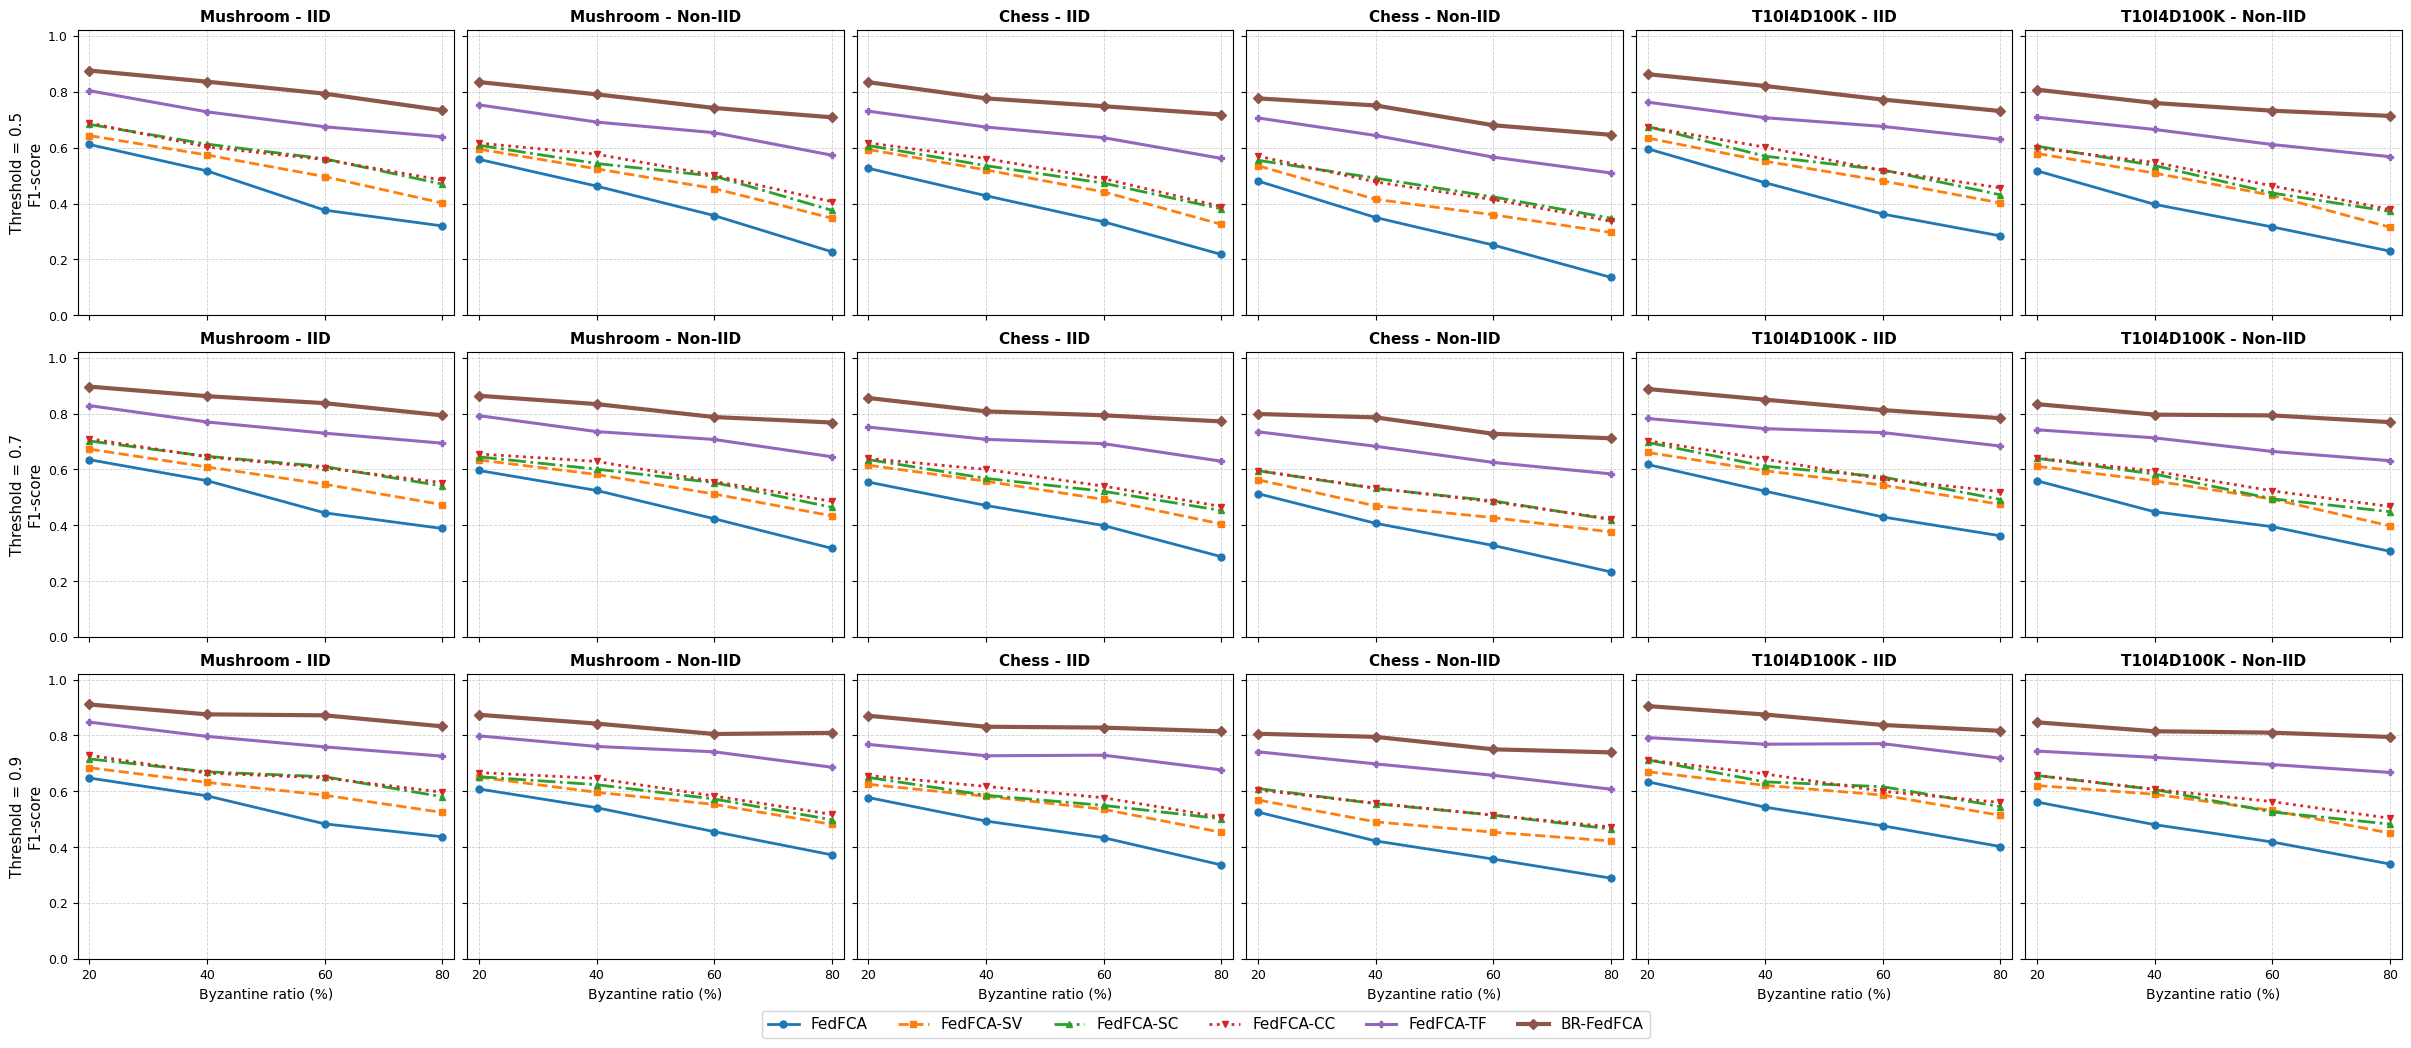

In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Load JSON results
# ============================================================

json_file = "F1_score.json"  # À ADAPTER

with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Ensure trustthreshold is treated as string
df["trustthreshold"] = df["trustthreshold"].astype(str)

# ============================================================
# Configuration
# ============================================================

datasets = ["mushroom", "chess", "T10I4D100K"]
partitions = ["IID", "Non-IID"]
thresholds = ["0.5", "0.7", "0.9"]

baselines = [
    "FedFCA",
    "FedFCA-SV",
    "FedFCA-SC",
    "FedFCA-CC",
    "FedFCA-TF",
    "BR-FedFCA"
]

labels = {
    "mushroom": "Mushroom",
    "chess": "Chess",
    "T10I4D100K": "T10I4D100K"
}

styles = {
    "FedFCA": {
        "marker": "o",
        "linewidth": 2.0,
        "linestyle": "-"
    },
    "FedFCA-SV": {
        "marker": "s",
        "linewidth": 2.0,
        "linestyle": "--"
    },
    "FedFCA-SC": {
        "marker": "^",
        "linewidth": 2.0,
        "linestyle": "-."
    },
    "FedFCA-CC": {
        "marker": "v",
        "linewidth": 2.0,
        "linestyle": ":"
    },
    "FedFCA-TF": {
        "marker": "P",
        "linewidth": 2.2,
        "linestyle": "-"
    },
    "BR-FedFCA": {
        "marker": "D",
        "linewidth": 3.0,
        "linestyle": "-"
    }
}

# ============================================================
# Plot: 3 rows × 6 columns
# ============================================================

fig, axes = plt.subplots(
    3,
    6,
    figsize=(24, 10),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for row, threshold in enumerate(thresholds):

    col = 0

    for dataset in datasets:
        for partition in partitions:

            ax = axes[row, col]

            subset = df[
                (df["dataset"] == dataset) &
                (df["partition"] == partition) &
                (df["trustthreshold"] == threshold)
            ]

            for baseline in baselines:
                baseline_data = subset[
                    subset["baseline"] == baseline
                ].sort_values("byzantine_ratio")

                ax.plot(
                    baseline_data["byzantine_ratio"],
                    baseline_data["f1_score"],
                    label=baseline,
                    marker=styles[baseline]["marker"],
                    linewidth=styles[baseline]["linewidth"],
                    linestyle=styles[baseline]["linestyle"],
                    markersize=5
                )

            ax.set_title(
                f"{labels[dataset]} - {partition}",
                fontsize=11,
                fontweight="bold"
            )

            if col == 0:
                ax.set_ylabel(
                    f"Threshold = {threshold}\nF1-score",
                    fontsize=11
                )

            if row == 2:
                ax.set_xlabel(
                    "Byzantine ratio (%)",
                    fontsize=10
                )

            ax.set_xlim(18, 82)
            ax.set_ylim(0, 1.02)
            ax.set_xticks([20, 40, 60, 80])
            ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

            ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
            ax.tick_params(axis="both", labelsize=9)

            col += 1

# ============================================================
# Global legend
# ============================================================

handles, legend_labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=6,
    fontsize=11,
    frameon=True,
    bbox_to_anchor=(0.5, -0.04)
)

# ============================================================
# Save figure
# ============================================================

plt.savefig(
    "f1_score_thresholds_3x6.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.savefig(
    "f1_score_thresholds_3x6.png",
    format="png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:

import json
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Load JSON runtime results
# ============================================================

json_file = "Code collé(22).json"  # À ADAPTER

with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# ============================================================
# Configuration
# ============================================================

datasets = ["mushroom", "chess", "T10I4D100K"]
partitions = ["IID", "Non-IID"]

baselines = [
    "FedFCA",
    "FedFCA-SV",
    "FedFCA-SC",
    "FedFCA-CC",
    "FedFCA-TF",
    "BR-FedFCA"
]

dataset_labels = {
    "mushroom": "Mushroom",
    "chess": "Chess",
    "T10I4D100K": "T10I4D100K"
}

styles = {
    "FedFCA": {"marker": "o", "linewidth": 2.0, "linestyle": "-"},
    "FedFCA-SV": {"marker": "s", "linewidth": 2.0, "linestyle": "--"},
    "FedFCA-SC": {"marker": "^", "linewidth": 2.0, "linestyle": "-."},
    "FedFCA-CC": {"marker": "v", "linewidth": 2.0, "linestyle": ":"},
    "FedFCA-TF": {"marker": "P", "linewidth": 2.2, "linestyle": "-"},
    "BR-FedFCA": {"marker": "D", "linewidth": 3.0, "linestyle": "-"}
}

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 8),
    sharex=True,
    sharey=False,
    constrained_layout=True
)

for row, partition in enumerate(partitions):
    for col, dataset in enumerate(datasets):

        ax = axes[row, col]

        subset = df[
            (df["dataset"] == dataset) &
            (df["partition"] == partition)
        ]

        for baseline in baselines:
            baseline_data = subset[
                subset["baseline"] == baseline
            ].sort_values("participants")

            ax.plot(
                baseline_data["participants"],
                baseline_data["runtime_seconds"],
                label=baseline,
                marker=styles[baseline]["marker"],
                linewidth=styles[baseline]["linewidth"],
                linestyle=styles[baseline]["linestyle"],
                markersize=5
            )

        ax.set_title(
            f"{dataset_labels[dataset]} - {partition}",
            fontsize=13,
            fontweight="bold"
        )

        ax.set_xlabel("Number of participants", fontsize=11)

        if col == 0:
            ax.set_ylabel("Runtime (seconds)", fontsize=11)

        ax.set_xticks([50, 100, 150, 200, 250])
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
        ax.tick_params(axis="both", labelsize=10)

# ============================================================
# Global legend
# ============================================================

handles, legend_labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=6,
    fontsize=11,
    frameon=True,
    bbox_to_anchor=(0.5, -0.04)
)

# ============================================================
# Save figure
# ============================================================

plt.savefig(
    "runtime_participants_iid_non_iid.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.savefig(
    "runtime_participants_iid_non_iid.png",
    format="png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


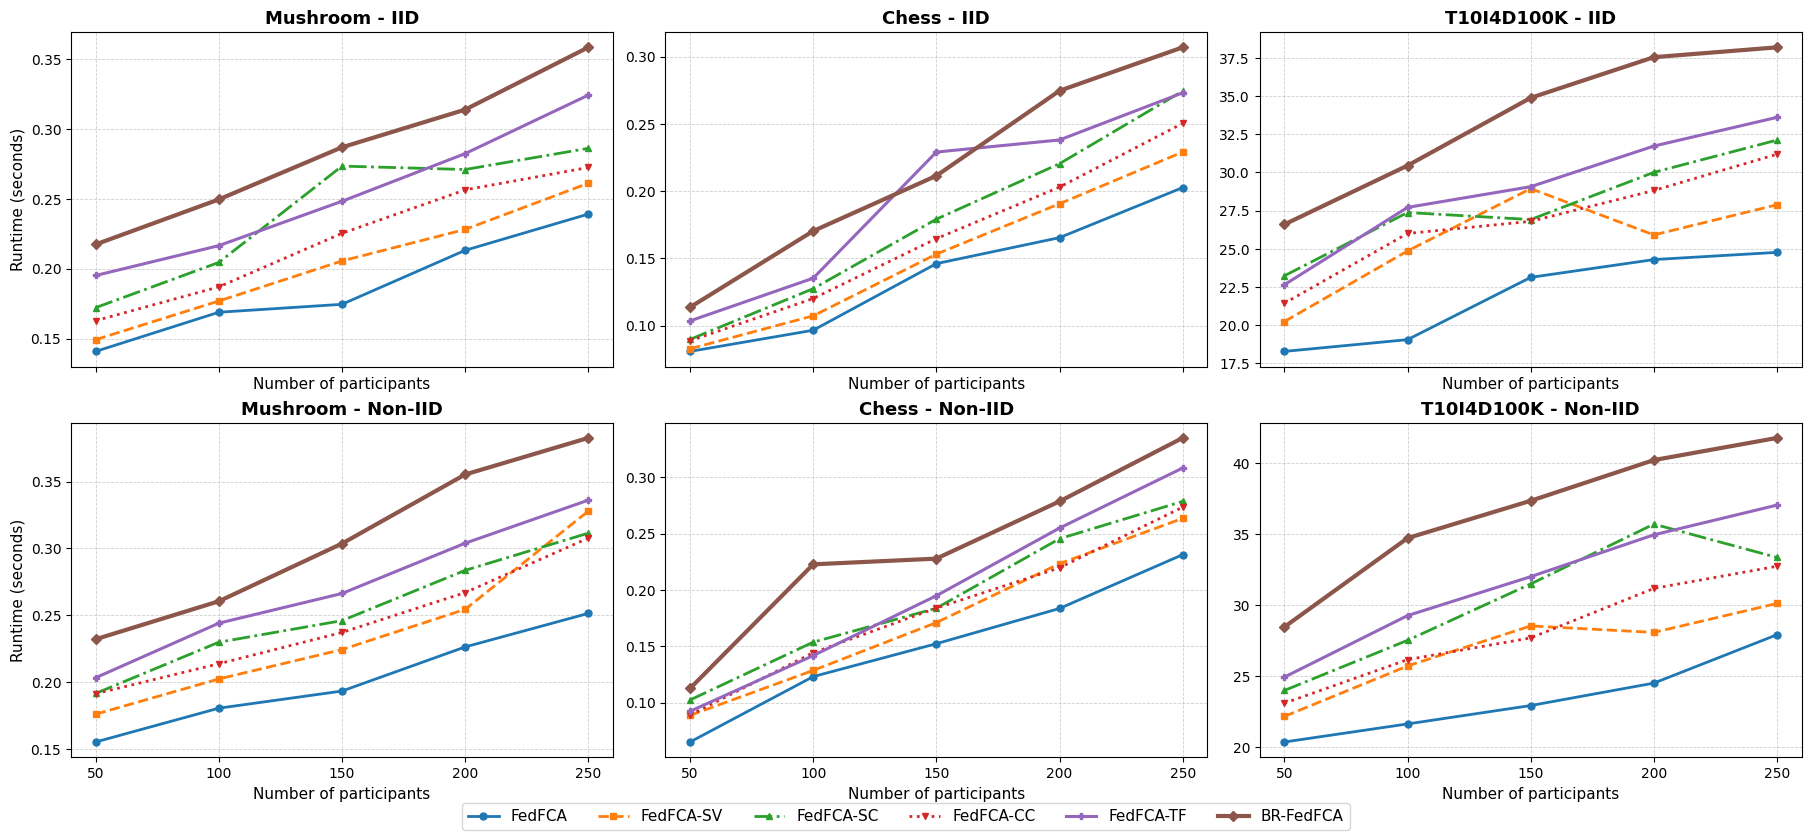

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Load JSON runtime results
# ============================================================

json_file = "runtime.json"  # À ADAPTER

with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# ============================================================
# Configuration
# ============================================================

datasets = ["mushroom", "chess", "T10I4D100K"]
partitions = ["IID", "Non-IID"]

baselines = [
    "FedFCA",
    "FedFCA-SV",
    "FedFCA-SC",
    "FedFCA-CC",
    "FedFCA-TF",
    "BR-FedFCA"
]

dataset_labels = {
    "mushroom": "Mushroom",
    "chess": "Chess",
    "T10I4D100K": "T10I4D100K"
}

styles = {
    "FedFCA": {"marker": "o", "linewidth": 2.0, "linestyle": "-"},
    "FedFCA-SV": {"marker": "s", "linewidth": 2.0, "linestyle": "--"},
    "FedFCA-SC": {"marker": "^", "linewidth": 2.0, "linestyle": "-."},
    "FedFCA-CC": {"marker": "v", "linewidth": 2.0, "linestyle": ":"},
    "FedFCA-TF": {"marker": "P", "linewidth": 2.2, "linestyle": "-"},
    "BR-FedFCA": {"marker": "D", "linewidth": 3.0, "linestyle": "-"}
}

# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 8),
    sharex=True,
    sharey=False,
    constrained_layout=True
)

for row, partition in enumerate(partitions):
    for col, dataset in enumerate(datasets):

        ax = axes[row, col]

        subset = df[
            (df["dataset"] == dataset) &
            (df["partition"] == partition)
        ]

        for baseline in baselines:
            baseline_data = subset[
                subset["baseline"] == baseline
            ].sort_values("participants")

            ax.plot(
                baseline_data["participants"],
                baseline_data["runtime_seconds"],
                label=baseline,
                marker=styles[baseline]["marker"],
                linewidth=styles[baseline]["linewidth"],
                linestyle=styles[baseline]["linestyle"],
                markersize=5
            )

        ax.set_title(
            f"{dataset_labels[dataset]} - {partition}",
            fontsize=13,
            fontweight="bold"
        )

        ax.set_xlabel("Number of participants", fontsize=11)

        if col == 0:
            ax.set_ylabel("Runtime (seconds)", fontsize=11)

        ax.set_xticks([50, 100, 150, 200, 250])
        ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
        ax.tick_params(axis="both", labelsize=10)

# ============================================================
# Global legend
# ============================================================

handles, legend_labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=6,
    fontsize=11,
    frameon=True,
    bbox_to_anchor=(0.5, -0.04)
)

# ============================================================
# Save figure
# ============================================================

plt.savefig(
    "runtime_participants_iid_non_iid.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.savefig(
    "runtime_participants_iid_non_iid.png",
    format="png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



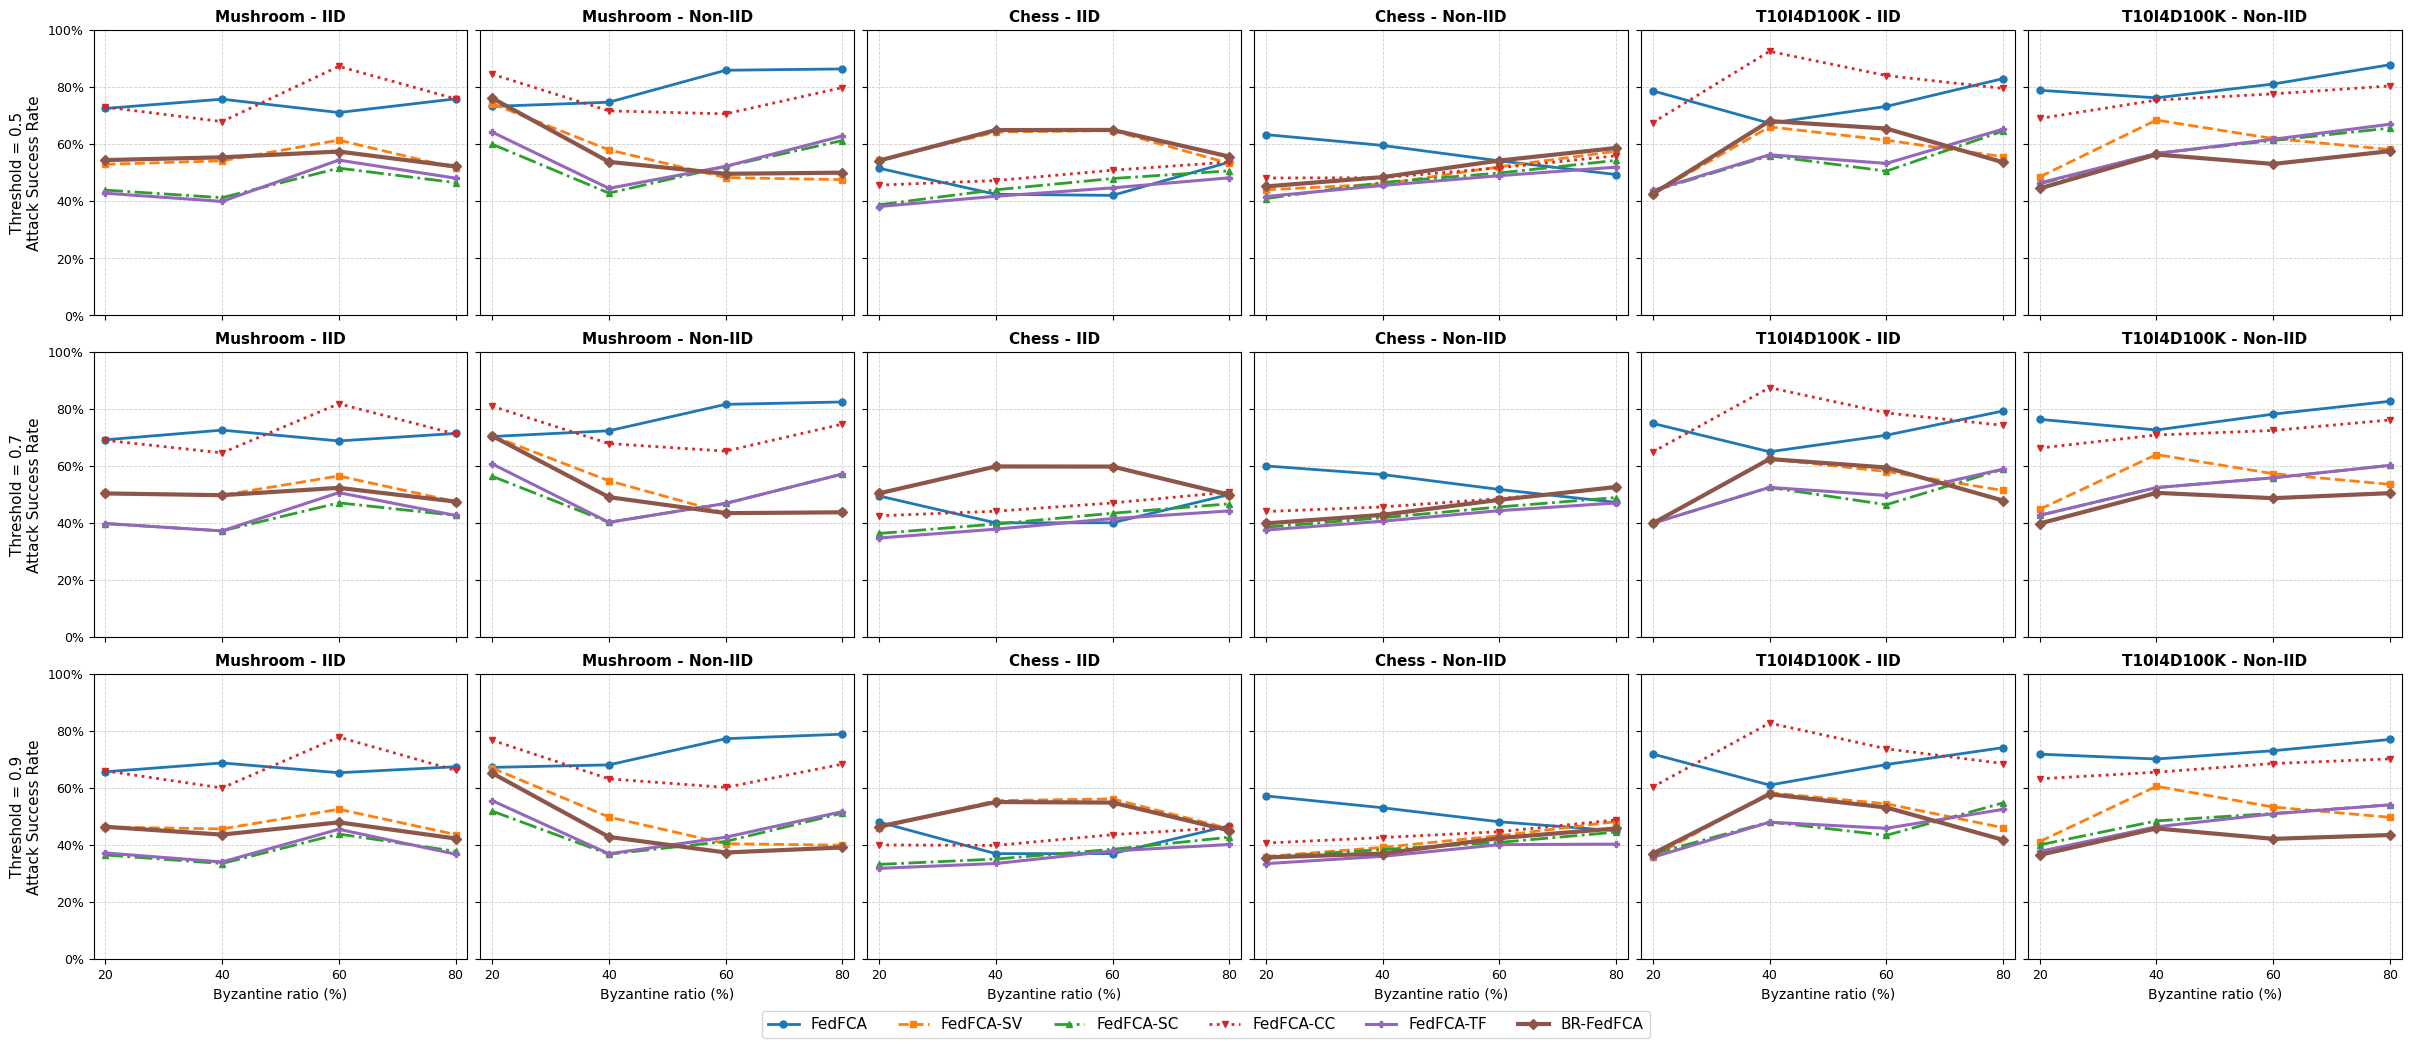

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ============================================================
# Load JSON ASR results
# ============================================================

json_file = "attack_success_rate.json"  # À ADAPTER

with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Ensure trustthreshold is treated as string
df["trustthreshold"] = df["trustthreshold"].astype(str)

# ============================================================
# Configuration
# ============================================================

datasets = ["mushroom", "chess", "T10I4D100K"]
partitions = ["IID", "Non-IID"]
thresholds = ["0.5", "0.7", "0.9"]

baselines = [
    "FedFCA",
    "FedFCA-SV",
    "FedFCA-SC",
    "FedFCA-CC",
    "FedFCA-TF",
    "BR-FedFCA"
]

dataset_labels = {
    "mushroom": "Mushroom",
    "chess": "Chess",
    "T10I4D100K": "T10I4D100K"
}

styles = {
    "FedFCA": {"marker": "o", "linewidth": 2.0, "linestyle": "-"},
    "FedFCA-SV": {"marker": "s", "linewidth": 2.0, "linestyle": "--"},
    "FedFCA-SC": {"marker": "^", "linewidth": 2.0, "linestyle": "-."},
    "FedFCA-CC": {"marker": "v", "linewidth": 2.0, "linestyle": ":"},
    "FedFCA-TF": {"marker": "P", "linewidth": 2.2, "linestyle": "-"},
    "BR-FedFCA": {"marker": "D", "linewidth": 3.0, "linestyle": "-"}
}

# ============================================================
# Plot: 3 rows × 6 columns
# ============================================================

fig, axes = plt.subplots(
    3,
    6,
    figsize=(24, 10),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for row, threshold in enumerate(thresholds):

    col = 0

    for dataset in datasets:
        for partition in partitions:

            ax = axes[row, col]

            subset = df[
                (df["dataset"] == dataset) &
                (df["partition"] == partition) &
                (df["trustthreshold"] == threshold)
            ]

            for baseline in baselines:

                baseline_data = subset[
                    subset["baseline"] == baseline
                ].sort_values("byzantine_ratio")

                if baseline_data.empty:
                    continue

                ax.plot(
                    baseline_data["byzantine_ratio"],
                    baseline_data["attack_success_rate"],
                    label=baseline,
                    marker=styles[baseline]["marker"],
                    linewidth=styles[baseline]["linewidth"],
                    linestyle=styles[baseline]["linestyle"],
                    markersize=5
                )

            ax.set_title(
                f"{dataset_labels[dataset]} - {partition}",
                fontsize=11,
                fontweight="bold"
            )

            if col == 0:
                ax.set_ylabel(
                    f"Threshold = {threshold}\nAttack Success Rate",
                    fontsize=11
                )

            if row == 2:
                ax.set_xlabel(
                    "Byzantine ratio (%)",
                    fontsize=10
                )

            ax.set_xlim(18, 82)
            ax.set_ylim(0, 100)

            ax.set_xticks([20, 40, 60, 80])
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

            ax.grid(
                True,
                linestyle="--",
                linewidth=0.6,
                alpha=0.6
            )

            ax.tick_params(
                axis="both",
                labelsize=9
            )

            col += 1

# ============================================================
# Global legend
# ============================================================

handles, legend_labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=6,
    fontsize=11,
    frameon=True,
    bbox_to_anchor=(0.5, -0.04)
)

# ============================================================
# Save figures
# ============================================================

plt.savefig(
    "attack_success_rate_thresholds_3x6.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.savefig(
    "attack_success_rate_thresholds_3x6.png",
    format="png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

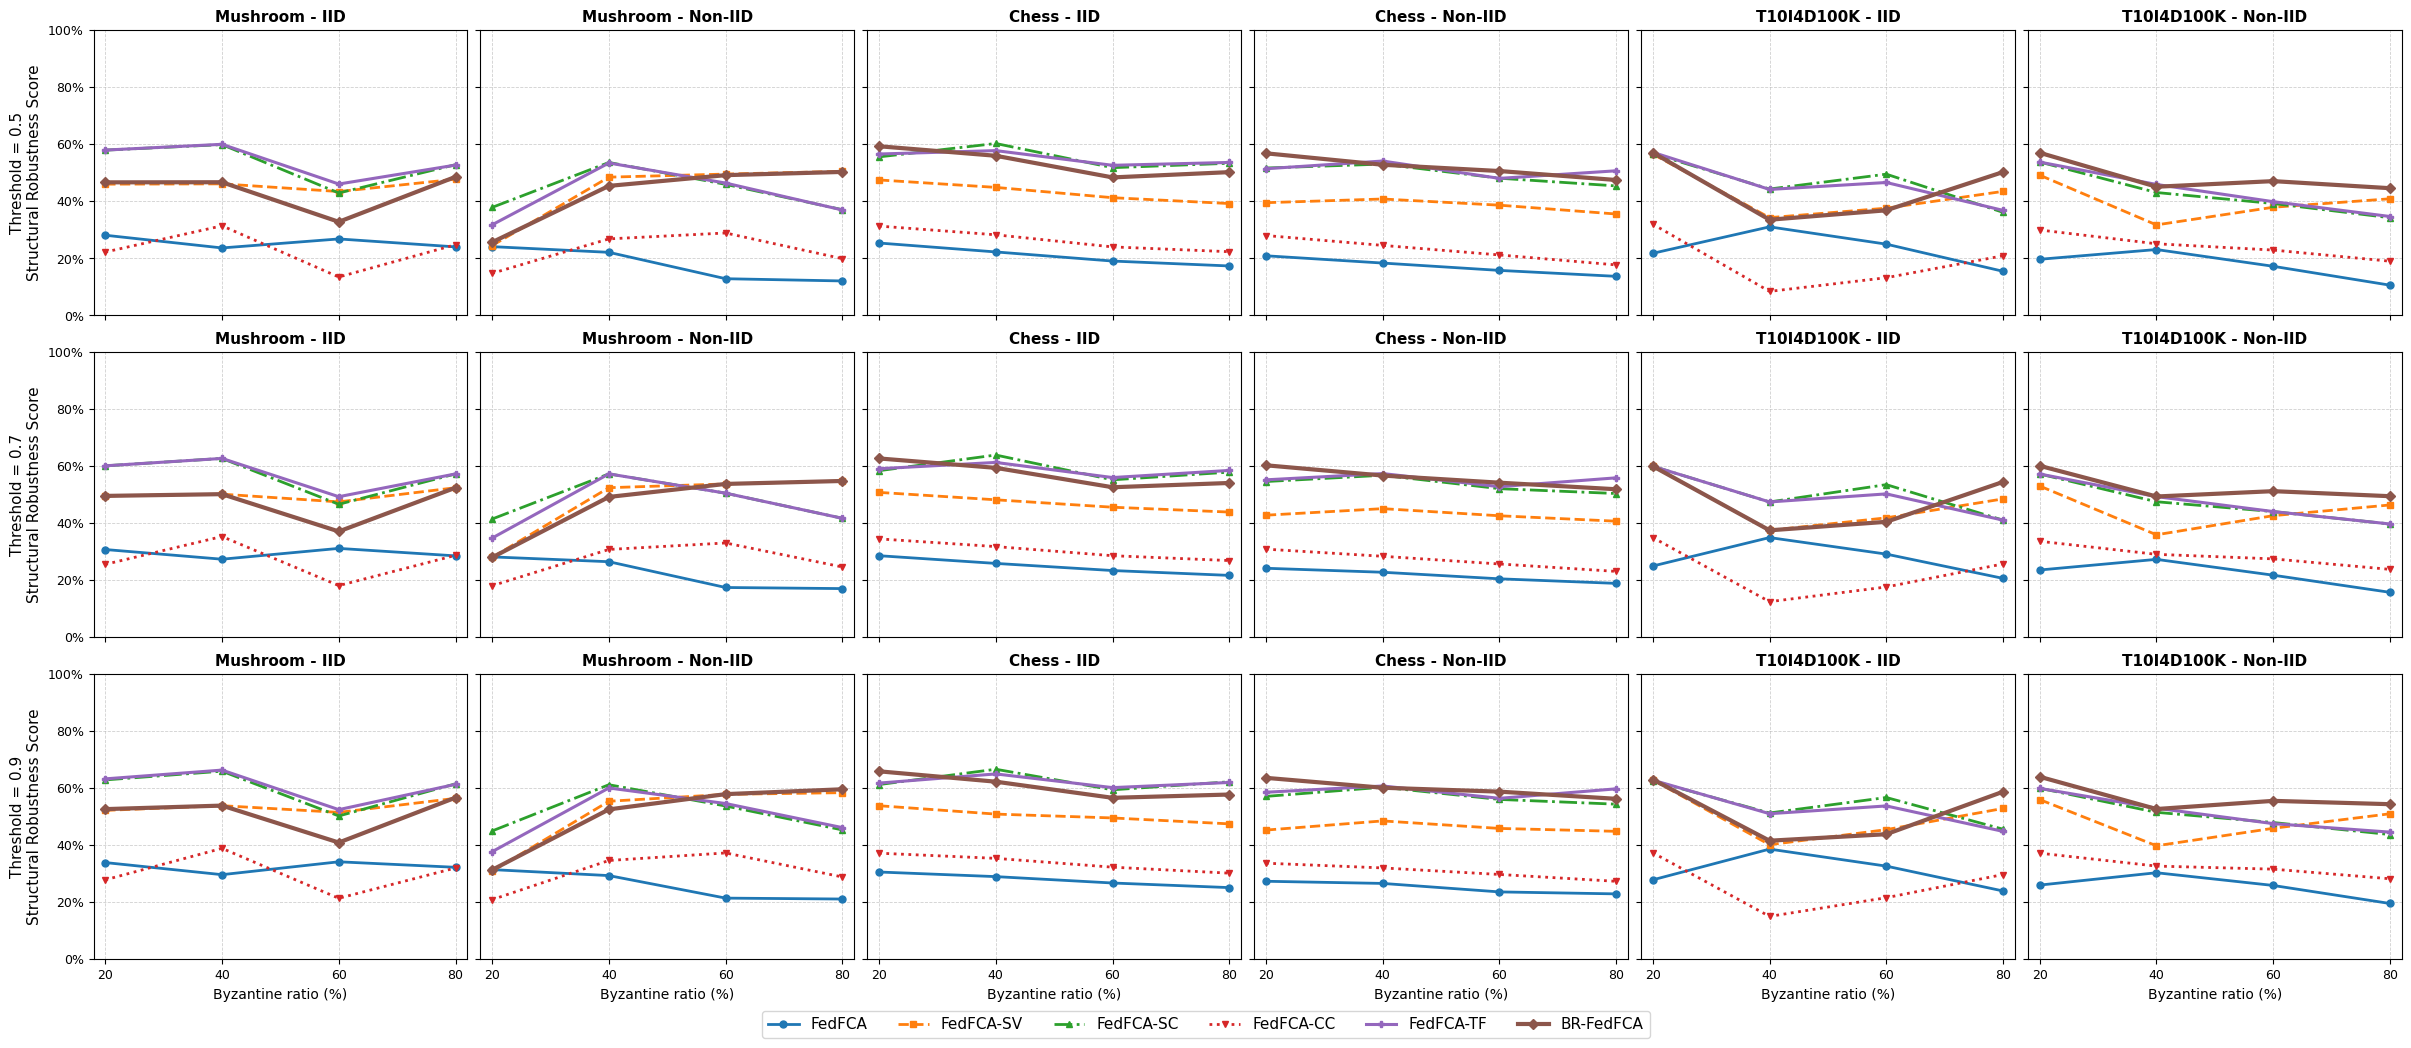

In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ============================================================
# Load JSON Structural Robustness results
# ============================================================

json_file = "structural_robustness_score.json"  # À ADAPTER

with open(json_file, "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Ensure trustthreshold is treated as string
df["trustthreshold"] = df["trustthreshold"].astype(str)

# ============================================================
# Configuration
# ============================================================

datasets = ["mushroom", "chess", "T10I4D100K"]
partitions = ["IID", "Non-IID"]
thresholds = ["0.5", "0.7", "0.9"]

baselines = [
    "FedFCA",
    "FedFCA-SV",
    "FedFCA-SC",
    "FedFCA-CC",
    "FedFCA-TF",
    "BR-FedFCA"
]

dataset_labels = {
    "mushroom": "Mushroom",
    "chess": "Chess",
    "T10I4D100K": "T10I4D100K"
}

styles = {
    "FedFCA": {"marker": "o", "linewidth": 2.0, "linestyle": "-"},
    "FedFCA-SV": {"marker": "s", "linewidth": 2.0, "linestyle": "--"},
    "FedFCA-SC": {"marker": "^", "linewidth": 2.0, "linestyle": "-."},
    "FedFCA-CC": {"marker": "v", "linewidth": 2.0, "linestyle": ":"},
    "FedFCA-TF": {"marker": "P", "linewidth": 2.2, "linestyle": "-"},
    "BR-FedFCA": {"marker": "D", "linewidth": 3.0, "linestyle": "-"}
}

# ============================================================
# Plot: 3 rows × 6 columns
# ============================================================

fig, axes = plt.subplots(
    3,
    6,
    figsize=(24, 10),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

for row, threshold in enumerate(thresholds):

    col = 0

    for dataset in datasets:
        for partition in partitions:

            ax = axes[row, col]

            subset = df[
                (df["dataset"] == dataset) &
                (df["partition"] == partition) &
                (df["trustthreshold"] == threshold)
            ]

            for baseline in baselines:

                baseline_data = subset[
                    subset["baseline"] == baseline
                ].sort_values("byzantine_ratio")

                if baseline_data.empty:
                    continue

                ax.plot(
                    baseline_data["byzantine_ratio"],
                    baseline_data["structural_robustness_score"],
                    label=baseline,
                    marker=styles[baseline]["marker"],
                    linewidth=styles[baseline]["linewidth"],
                    linestyle=styles[baseline]["linestyle"],
                    markersize=5
                )

            ax.set_title(
                f"{dataset_labels[dataset]} - {partition}",
                fontsize=11,
                fontweight="bold"
            )

            if col == 0:
                ax.set_ylabel(
                    f"Threshold = {threshold}\nStructural Robustness Score",
                    fontsize=11
                )

            if row == 2:
                ax.set_xlabel(
                    "Byzantine ratio (%)",
                    fontsize=10
                )

            ax.set_xlim(18, 82)
            ax.set_ylim(0, 100)

            ax.set_xticks([20, 40, 60, 80])
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))

            ax.grid(
                True,
                linestyle="--",
                linewidth=0.6,
                alpha=0.6
            )

            ax.tick_params(
                axis="both",
                labelsize=9
            )

            col += 1

# ============================================================
# Global legend
# ============================================================

handles, legend_labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=6,
    fontsize=11,
    frameon=True,
    bbox_to_anchor=(0.5, -0.04)
)

# ============================================================
# Save figures
# ============================================================

plt.savefig(
    "structural_robustness_thresholds_3x6.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.savefig(
    "structural_robustness_thresholds_3x6.png",
    format="png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()